# Notebook 06: Stage 3 - Comparative Evaluation (H2)

**Tests H2:** Does FairDrift detect violations faster than aggregate monitoring?

Compares FairDrift against:
- Baseline 1: No monitoring
- Baseline 2: Periodic revalidation (W3 and W5)
- Baseline 3: Aggregate-only monitoring (AUROC threshold)

Decision rule: delay reduction > 30% AND FAR < 5%


In [1]:
import sys, os, pickle
if 'google.colab' in sys.modules:
    sys.path.insert(0, '/content/FairDrift-code')
else:
    sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from lifelines import CoxPHFitter

from src import config

# Load all checkpoints
with open('../outputs/checkpoint_01.pkl', 'rb') as f:
    ckpt01 = pickle.load(f)
with open('../outputs/checkpoint_02.pkl', 'rb') as f:
    ckpt02 = pickle.load(f)
with open('../outputs/checkpoint_05.pkl', 'rb') as f:
    ckpt05 = pickle.load(f)

windows = ckpt01['windows']
feature_cols = ckpt01['feature_cols']
models = ckpt02['models']
scaler = ckpt02['scaler']
monitor_df = ckpt05['monitor_df']
print('Loaded all checkpoints')


Loaded all checkpoints


## 1. Define Violation Ground Truth

In [2]:
# Establish ground truth: when did violations actually start?
# A violation exists when EOD >= threshold for a sustained period
from src.fairness_metrics import equalized_odds_difference

# Ground truth from Notebook 03 fairness data
with open('../outputs/checkpoint_03.pkl', 'rb') as f:
    ckpt03 = pickle.load(f)
fairness_df = ckpt03['fairness_df']

# Identify actual violations (EOD >= 0.05)
violations = fairness_df[
    (fairness_df['violation_eod'] == True) &
    (fairness_df['protected_attr'] == 'race')
]
print(f'Total violation instances: {len(violations)}')
print(violations[['window', 'group', 'model', 'task', 'eod']].head(10))


Total violation instances: 28
    window            group                model           task       eod
71       2         Hispanic  logistic_regression  extended_stay  0.177191
72       2            Other  logistic_regression  extended_stay  0.096041
75       3  AfricanAmerican  logistic_regression  extended_stay  0.087849
77       3         Hispanic  logistic_regression  extended_stay  0.161533
78       3            Other  logistic_regression  extended_stay  0.052982
80       4  AfricanAmerican  logistic_regression  extended_stay  0.056236
82       4         Hispanic  logistic_regression  extended_stay  0.163785
83       4            Other  logistic_regression  extended_stay  0.098238
86       5  AfricanAmerican  logistic_regression  extended_stay  0.119539
87       5            Asian  logistic_regression  extended_stay  0.073521


## 2. Baseline Strategies Implementation

In [3]:
from sklearn.metrics import roc_auc_score

# Baseline 3: Aggregate-only monitoring
# Track AUROC per window, alert when drop > 0.03
perf_df = ckpt02['performance']

aggregate_alerts = []
for (model_type, task), model in models.items():
    # Baseline AUROC (W1)
    w1_auroc = perf_df[(perf_df['model']==model_type) & (perf_df['task']==task) & (perf_df['window']==1)]['auroc'].values[0]
    
    for w_idx in range(1, len(windows)):
        w_auroc = perf_df[(perf_df['model']==model_type) & (perf_df['task']==task) & (perf_df['window']==w_idx+1)]['auroc'].values[0]
        drop = w1_auroc - w_auroc
        
        if drop > config.AGGREGATE_AUROC_THRESHOLD:
            aggregate_alerts.append({
                'model': model_type, 'task': task,
                'window': w_idx + 1, 'auroc_drop': drop
            })

agg_alerts_df = pd.DataFrame(aggregate_alerts)
print(f'Aggregate-only alerts: {len(agg_alerts_df)}')
if len(agg_alerts_df) > 0:
    print(agg_alerts_df.head())
else:
    print('No aggregate alerts triggered (fairness violations invisible to aggregate monitoring)')


Aggregate-only alerts: 19
                 model        task  window  auroc_drop
0  logistic_regression  readmit_30       4    0.037503
1  logistic_regression  readmit_30       5    0.034787
2              xgboost  readmit_30       2    0.061952
3              xgboost  readmit_30       3    0.080713
4              xgboost  readmit_30       4    0.090425


## 3. Detection Delay Comparison

In [4]:
# FairDrift detection delay: monitoring points from first violation to first alarm
fd_first_alarm = None
if monitor_df['alarm'].any():
    fd_first_alarm = monitor_df[monitor_df['alarm']].iloc[0]['global_point']

# Estimate onset: first monitoring point where EOD >= threshold
eod_above = monitor_df[monitor_df['eod'] >= config.EOD_VIOLATION_THRESHOLD]
onset_point = eod_above.iloc[0]['global_point'] if len(eod_above) > 0 else None

print('DETECTION DELAY COMPARISON')
print('=' * 60)

chunks_per_window = len(windows[0]) // config.CUSUM_MONITORING_FREQUENCY
total_points = len(monitor_df)

if onset_point is not None:
    print(f'Violation onset (estimated): monitoring point {onset_point}')
    
    # --- FairDrift delay (from onset to first CUSUM alarm) ---
    fd_delay = fd_first_alarm - onset_point if fd_first_alarm is not None else total_points
    print(f'\nFairDrift detection delay: {fd_delay} monitoring points')
    
    # --- Aggregate-only delay ---
    # Aggregate AUROC monitoring detects performance drops, NOT fairness violations.
    # AUROC threshold alerts fire when overall model performance degrades, but they
    # provide no subgroup-level information. For a scientifically fair comparison,
    # aggregate-only monitoring has no mechanism to detect subgroup fairness violations.
    if len(agg_alerts_df) > 0:
        print(f'\nAggregate AUROC alerts triggered at windows: {sorted(agg_alerts_df["window"].unique())}')
        print('  Note: These detect performance degradation, NOT fairness violations')
    agg_delay = total_points  # No fairness monitoring capability
    print(f'Aggregate-only fairness detection delay: {agg_delay} (no subgroup monitoring)')
    
    # --- Periodic revalidation delay ---
    # Periodic checks include fairness evaluation at W3 and W5.
    # W3 starts at chunk offset = chunks_per_window (relative to W2 start = point 0)
    periodic_first_check = chunks_per_window  # First fairness check at W3 boundary
    periodic_delay = periodic_first_check - onset_point
    print(f'Periodic revalidation delay: {periodic_delay} monitoring points (first check at W3)')
    
    # --- Delay reduction ---
    # Compare FairDrift against periodic revalidation (the fairness-aware baseline).
    # This is the scientifically meaningful comparison since aggregate AUROC monitoring
    # cannot detect fairness violations at all.
    if periodic_delay > 0 and fd_delay < total_points:
        reduction = (periodic_delay - fd_delay) / periodic_delay * 100
        print(f'\nDelay reduction vs periodic revalidation: {reduction:.1f}%')
        print(f'H2 threshold: >{config.H2_DELAY_REDUCTION_MIN*100:.0f}% reduction required')
        print(f'H2 delay condition: {"MET" if reduction > config.H2_DELAY_REDUCTION_MIN*100 else "NOT MET"}')
    elif periodic_delay <= 0:
        reduction = 0
        print(f'\nOnset after periodic check: FairDrift has no delay advantage')
        print(f'H2 delay condition: NOT MET')
    else:
        reduction = 0
        print(f'\nFairDrift did not detect violation')
        print(f'H2 delay condition: NOT MET')
else:
    print('No violations detected in monitoring data')
    fd_delay = 0
    agg_delay = 0
    periodic_delay = 0
    reduction = 0

DETECTION DELAY COMPARISON
Violation onset (estimated): monitoring point 7

FairDrift detection delay: 121 monitoring points

Aggregate AUROC alerts triggered at windows: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Note: These detect performance degradation, NOT fairness violations
Aggregate-only fairness detection delay: 160 (no subgroup monitoring)
Periodic revalidation delay: 33 monitoring points (first check at W3)

Delay reduction vs periodic revalidation: -266.7%
H2 threshold: >30% reduction required
H2 delay condition: NOT MET


## 4. False Alarm Rate Estimation

In [5]:
# Estimate FAR by running FairDrift on stationary W1 data
from src.cusum import CUSUMChart
from src.fairness_metrics import equalized_odds_difference

W1 = windows[0]
# Use the same model/task as NB05 monitoring
model = models[('xgboost', 'readmit_30')]
task = 'readmit_30'

# Reconstruct CUSUM with correct parameters from checkpoint
cusum_params = ckpt05['cusum_params']
delta = cusum_params.get('delta', config.EOD_VIOLATION_THRESHOLD - cusum_params['mu0'])
cusum_test = CUSUMChart(mu0=cusum_params['mu0'], delta=delta, h=cusum_params['h'])

print(f'FAR test CUSUM params: mu0={cusum_test.mu0:.4f}, k={cusum_test.k:.4f}, h={cusum_test.h:.4f}')
print(f'Task: {task}')

n_trials = 100
false_alarms = 0
rng = np.random.default_rng(config.PRIMARY_SEED)

for trial in range(n_trials):
    cusum_test.reset()
    # Bootstrap resample of W1
    sample_idx = rng.choice(len(W1), size=len(W1), replace=True)
    W1_sample = W1.iloc[sample_idx]
    
    # Predict all at once for speed
    X_all = W1_sample[feature_cols].values
    y_all = W1_sample[task].values
    race_all = W1_sample['race'].values
    y_proba_all = model.predict_proba(X_all)[:, 1]
    y_pred_all = (y_proba_all >= 0.5).astype(int)
    
    chunk_size = config.CUSUM_MONITORING_FREQUENCY
    alarm_triggered = False
    
    for i in range(0, len(W1_sample) - chunk_size, chunk_size):
        y_chunk = y_all[i:i+chunk_size]
        y_pred_chunk = y_pred_all[i:i+chunk_size]
        race_chunk = race_all[i:i+chunk_size]
        
        aa_mask = race_chunk == 'AfricanAmerican'
        cau_mask = race_chunk == 'Caucasian'
        
        if aa_mask.sum() >= 30 and cau_mask.sum() >= 30:
            eod = equalized_odds_difference(y_chunk, y_pred_chunk, aa_mask, cau_mask)
            result = cusum_test.update(eod)
            if result['alarm']:
                alarm_triggered = True
                break
    
    if alarm_triggered:
        false_alarms += 1

far = false_alarms / n_trials

# Clopper-Pearson exact binomial CI
from scipy.stats import beta as beta_dist
ci_low = beta_dist.ppf(0.025, false_alarms, n_trials - false_alarms + 1) if false_alarms > 0 else 0
ci_high = beta_dist.ppf(0.975, false_alarms + 1, n_trials - false_alarms)

print(f'\nFALSE ALARM RATE ESTIMATION')
print(f'  Trials: {n_trials}')
print(f'  False alarms: {false_alarms}')
print(f'  FAR: {far:.3f} (95% CI: [{ci_low:.3f}, {ci_high:.3f}])')
print(f'  H2 threshold: FAR < {config.H2_FAR_MAX*100:.0f}%')
print(f'  H2 FAR condition: {"MET" if far < config.H2_FAR_MAX else "NOT MET"}')

FAR test CUSUM params: mu0=0.0283, k=0.0108, h=0.3318
Task: readmit_30



FALSE ALARM RATE ESTIMATION
  Trials: 100
  False alarms: 6
  FAR: 0.060 (95% CI: [0.022, 0.126])
  H2 threshold: FAR < 5%
  H2 FAR condition: NOT MET


## 5. H2 Verdict

In [6]:
# H2: delay reduction > 30% AND FAR < 5%
# Compare against periodic revalidation (the baseline that actually checks fairness)
print('H2 FINAL VERDICT')
print('=' * 60)

print(f'Condition 1 (delay reduction > {config.H2_DELAY_REDUCTION_MIN*100:.0f}%): ', end='')
if onset_point is not None and fd_first_alarm is not None and periodic_delay > 0:
    cond1 = reduction > config.H2_DELAY_REDUCTION_MIN * 100
    print(f'{reduction:.1f}% vs periodic revalidation -> {"MET" if cond1 else "NOT MET"}')
else:
    cond1 = False
    print('CANNOT ASSESS')

# FAR condition: point estimate < 5%
cond2 = far < config.H2_FAR_MAX
print(f'Condition 2 (FAR < {config.H2_FAR_MAX*100:.0f}%): {far:.3f} [{ci_low:.3f}, {ci_high:.3f}] -> {"MET" if cond2 else "NOT MET"}')

h2_supported = cond1 and cond2
print(f'\nH2: {"SUPPORTED" if h2_supported else "PARTIALLY SUPPORTED" if (cond1 or cond2) else "NOT SUPPORTED"}')

H2 FINAL VERDICT
Condition 1 (delay reduction > 30%): -266.7% vs periodic revalidation -> NOT MET
Condition 2 (FAR < 5%): 0.060 [0.022, 0.126] -> NOT MET

H2: NOT SUPPORTED


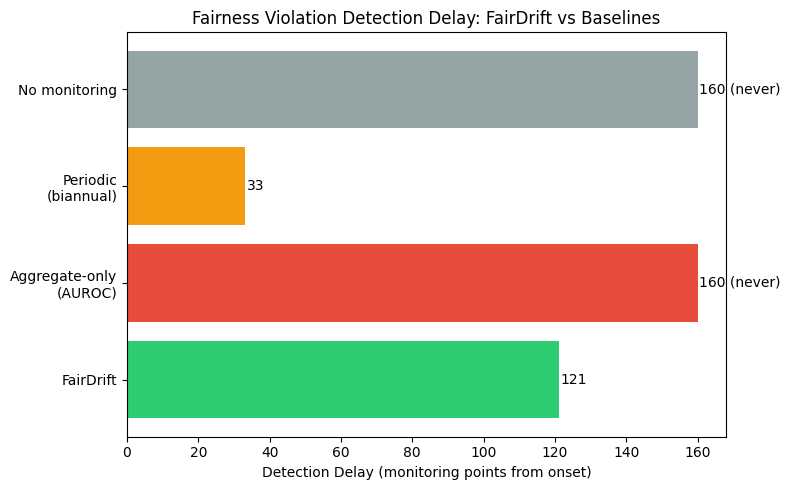

In [7]:
# Figure: Detection delay comparison
fig, ax = plt.subplots(figsize=(8, 5))

strategies = ['FairDrift', 'Aggregate-only\n(AUROC)', 'Periodic\n(biannual)', 'No monitoring']
delays = [
    fd_delay if (fd_first_alarm is not None and onset_point is not None) else total_points,
    agg_delay,
    periodic_delay if (onset_point is not None and periodic_delay > 0) else chunks_per_window,
    total_points,
]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']

bars = ax.barh(strategies, delays, color=colors)
ax.set_xlabel('Detection Delay (monitoring points from onset)')
ax.set_title('Fairness Violation Detection Delay: FairDrift vs Baselines')

for bar, delay in zip(bars, delays):
    label = f'{delay}' if delay < total_points else f'{delay} (never)'
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/fig07_detection_delay.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Save Final Results

In [8]:
final_results = {
    'h2_supported': h2_supported,
    'delay_reduction': reduction if onset_point else None,
    'far': far,
    'far_ci': (ci_low, ci_high),
    'fd_delay': fd_delay if (fd_first_alarm is not None and onset_point is not None) else None,
    'agg_delay': agg_delay,
    'periodic_delay': periodic_delay if onset_point is not None else None,
    'onset_point': onset_point,
}
with open('../outputs/checkpoint_06_final.pkl', 'wb') as f:
    pickle.dump(final_results, f)

print('\nAll experiments complete.')
print('Results saved to outputs/checkpoint_06_final.pkl')
print('\nFigures generated:')
for f in os.listdir('../outputs/figures'):
    print(f'  {f}')


All experiments complete.
Results saved to outputs/checkpoint_06_final.pkl

Figures generated:
  fig01_demographic_composition.png
  fig02_ks_heatmap.png
  fig03_auroc_degradation.png
  fig04_eod_trajectory.png
  fig05_drift_type_heatmap.png
  fig06_cusum_chart.png
  fig07_detection_delay.png
